### This notebook (python coding language based) will be our playground to analyse, study, find, understand patterns in spatial transcriptomics data from brain section !


---
![MouseBrain](https://github.com/Natarajanlab/CellularSafari/blob/main/receptor%20map%201.png?raw=true)

You will find some text (such as this block) intermixed with some coding blocks. The coding blocks can be run (using play-button on left of cell) to execture a command and provide a output.

We have provided some descriptors, so you can understand whats happening in each code block!


> The below command download and install some packages/softwares tools which we will use for analysis.

> *Have patience, this will take ~1-2minute to run and will show progress*

In [ ]:
!pip install scanpy squidpy numpy matplotlib seaborn scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of spatialdata to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip 

> Now we load those packages, including some for visualisation


In [ ]:
import scanpy as sc
import pandas as pd
import squidpy as sq
import seaborn as sns
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

> Below, we link our google drive (with actual data in a file called *'dataset_with_dapi.h5ad'*) and load it


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
adata = sc.read_h5ad(
    "/content/drive/MyDrive/Class_folder/dataset_with_dapi.h5ad"
)

In [ ]:
# @title RUN THIS CELL
img = adata.uns["spatial"]["library"]["images"]["hires"]

def plot_points(point_size = 0.5, alpha=0.4, figsize = (10,10)):
    coords = adata.obsm["spatial"]
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.scatter(
        coords[:,0],
        coords[:,1],
        s=point_size,
        c="red",
        alpha=alpha
    )

    plt.axis("off")
    plt.show()


def plot_spatial_annotation(
    adata,
    img = img,
    annotation="spatial_domain",
    resolution=None,
    neighbors_key=None,
    figsize=(9, 9),
    point_size=1,
    alpha=0.7,
    cmap_name="tab20",
):

    # ----------------------------------
    # Recompute Leiden if requested
    # ----------------------------------
    if annotation == "leiden" and resolution is not None:

        leiden_col = f"leiden_{resolution}"

        if leiden_col not in adata.obs:
            sc.tl.leiden(
                adata,
                resolution=resolution,
                key_added=leiden_col,
                neighbors_key=neighbors_key,
            )

        annotation = leiden_col

    coords = adata.obsm["spatial"]
    labels = adata.obs[annotation].astype(str)

    unique_labels = np.unique(labels)

    cmap = plt.get_cmap(cmap_name)
    colors = {
        lab: cmap(i % cmap.N)
        for i, lab in enumerate(unique_labels)
    }

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(img, cmap="gray")

    for lab in unique_labels:
        idx = labels == lab

        ax.scatter(
            coords[idx, 0],
            coords[idx, 1],
            s=point_size,
            color=colors[lab],
            alpha=alpha,
            label=lab,
        )

    ax.set_title(annotation)
    ax.axis("off")

    ax.legend(
        title=annotation,
        fontsize=7,
        title_fontsize=9,
        markerscale=2,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

def plot_two_annotations(
    adata,
    img = img,
    ann1="leiden",
    ann2="Cell Type",
    leiden_resolution=None,
    neighbors_key=None,
    figsize=(18, 7),
    point_size=1,
    alpha=0.7,
    cmap_name="tab20",
):

    # ----------------------------------
    # Handle Leiden resolution
    # ----------------------------------
    annotations = [ann1, ann2]

    if leiden_resolution is not None:

        leiden_col = f"leiden_{leiden_resolution}"

        if leiden_col not in adata.obs:
            sc.tl.leiden(
                adata,
                resolution=leiden_resolution,
                key_added=leiden_col,
                neighbors_key=neighbors_key,
            )

        annotations = [
            leiden_col if ann == "leiden" else ann
            for ann in annotations
        ]

    coords = adata.obsm["spatial"]
    cmap = plt.get_cmap(cmap_name)

    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    for ax, ann in zip(axes, annotations):

        labels = adata.obs[ann].astype(str)
        unique_labels = np.unique(labels)

        colors = {
            lab: cmap(i % cmap.N)
            for i, lab in enumerate(unique_labels)
        }

        ax.imshow(img, cmap="gray")

        for lab in unique_labels:
            idx = labels == lab

            ax.scatter(
                coords[idx, 0],
                coords[idx, 1],
                s=point_size,
                color=colors[lab],
                alpha=alpha,
                label=lab,
            )

        ax.set_title(ann)
        ax.axis("off")

        ax.legend(
            title=ann,
            fontsize=7,
            title_fontsize=9,
            markerscale=2,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            frameon=False,
        )

    plt.tight_layout()
    plt.show()

def spatial_density_maps(
    adata,
    label_key,
    img = img,
    grid_size=300,
    sigma=3,
    cmap="viridis"
):

    coords = adata.obsm["spatial"]
    labels = adata.obs[label_key].astype(str).values

    x, y = coords[:, 0], coords[:, 1]

    x_bins = np.linspace(x.min(), x.max(), grid_size)
    y_bins = np.linspace(y.min(), y.max(), grid_size)

    xi = np.clip(np.digitize(x, x_bins) - 1, 0, grid_size - 1)
    yi = np.clip(np.digitize(y, y_bins) - 1, 0, grid_size - 1)

    unique_labels = np.unique(labels)

    # store per-label density maps
    density_maps = {}

    for lab in unique_labels:

        mask = labels == lab

        heatmap = np.zeros((grid_size, grid_size), dtype=float)

        for i, j in zip(xi[mask], yi[mask]):
            heatmap[j, i] += 1

        # smooth density
        heatmap = gaussian_filter(heatmap, sigma=sigma)

        # normalize → probability-like map
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        density_maps[lab] = heatmap

    # -------------------------
    # plotting grid
    # -------------------------
    n = len(unique_labels)
    cols = 4
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()

    for i, lab in enumerate(unique_labels):
        ax = axes[i]

        ax.imshow(img, cmap="gray", origin="lower")

        im = ax.imshow(
            density_maps[lab],
            cmap=cmap,
            alpha=0.75,
            origin="lower",
            extent=[x.min(), x.max(), y.min(), y.max()]
        )

        ax.set_title(lab)
        ax.axis("off")

    # remove empty axes
    for j in range(len(unique_labels), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    return density_maps

def spatial_celltype_heatmap(
    adata,
    cell_types,
    img = img,
    sigma=3,
    grid_size=300,
    mode="sum"   # "sum", "mean", "any"
):

    coords = adata.obsm["spatial"]

    # -------------------------
    # normalize input
    # -------------------------
    if isinstance(cell_types, str):
        cell_types = [cell_types]

    # -------------------------
    # build cell-type matrix (cells × types)
    # -------------------------
    ct_matrix = np.vstack([
        (adata.obs["Cell Type"].values == ct).astype(float)
        for ct in cell_types
    ]).T

    # -------------------------
    # combine cell types
    # -------------------------
    if mode == "mean":
        score = ct_matrix.mean(axis=1)
    elif mode == "any":
        score = (ct_matrix.sum(axis=1) > 0).astype(float)
    else:  # "sum"
        score = ct_matrix.sum(axis=1)

    # -------------------------
    # spatial grid
    # -------------------------
    x = coords[:, 0]
    y = coords[:, 1]

    x_bins = np.linspace(x.min(), x.max(), grid_size)
    y_bins = np.linspace(y.min(), y.max(), grid_size)

    heatmap = np.zeros((grid_size, grid_size), dtype=float)

    xi = np.clip(np.digitize(x, x_bins) - 1, 0, grid_size - 1)
    yi = np.clip(np.digitize(y, y_bins) - 1, 0, grid_size - 1)

    for i, j, v in zip(xi, yi, score):
        heatmap[j, i] += float(v)

    # -------------------------
    # smoothing
    # -------------------------
    smooth = gaussian_filter(heatmap, sigma=sigma)

    # -------------------------
    # plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.imshow(img, cmap="gray", origin="lower")

    im = ax.imshow(
        smooth,
        cmap="coolwarm",
        alpha=0.5,
        origin="lower",
        extent=[
            x.min(), x.max(),
            y.min(), y.max()
        ]
    )

    ax.invert_yaxis()

    title_cts = ", ".join(cell_types)
    ax.set_title(f"Cell type heatmap: {title_cts}")
    ax.axis("off")

    plt.colorbar(im, ax=ax, label="cell-type density score")
    plt.show()


def plot_cell_types(cell_types, colors=None):
    # normalize input
    if isinstance(cell_types, str):
        cell_types = [cell_types]

    if colors is None:
        colors = plt.cm.tab10.colors  # default nice categorical palette

    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap="gray")

    for i, ct in enumerate(cell_types):
        mask = adata.obs["Cell Type"] == ct
        coords = adata.obsm["spatial"][mask]

        plt.scatter(
            coords[:, 0],
            coords[:, 1],
            s=2,
            c=[colors[i % len(colors)]],
            alpha=0.6,
            label=ct
        )

    plt.title("Selected cell types on DAPI")
    plt.axis("off")
    plt.legend(markerscale=5, fontsize=8)
    plt.show()


def spatial_genes_heatmap(
    adata,
    genes,
    img = img,
    sigma=3,
    grid_size=300,
    mode="mean"
):

    # -------------------------
    # normalize input
    # -------------------------
    if isinstance(genes, str):
        genes = [genes]

    coords = adata.obsm["spatial"]

    # -------------------------
    # collect expression
    # -------------------------
    expr_list = []

    for gene in genes:
        expr = adata[:, gene].X

        if hasattr(expr, "toarray"):
            expr = expr.toarray().ravel()
        else:
            expr = np.asarray(expr).ravel()

        expr_list.append(expr.astype(float))

    expr_stack = np.vstack(expr_list).T  # (cells × genes)

    # -------------------------
    # combine genes (extended modes)
    # -------------------------
    if mode == "sum":
        score = expr_stack.sum(axis=1)

    elif mode == "min":
        score = expr_stack.min(axis=1)

    elif mode == "max":
        score = expr_stack.max(axis=1)

    elif mode == "mean":
        score = expr_stack.mean(axis=1)

    elif mode == "any":
        score = (expr_stack > 0).any(axis=1).astype(float)

    elif mode == "geometric":
        # avoids log(0) issues
        score = np.exp(np.mean(np.log(expr_stack + 1e-9), axis=1))

    else:
        raise ValueError(f"Unknown mode: {mode}")

    score = np.asarray(score)

    # optional cleanup (kept but safer)
    if mode not in ["any"]:
        score[score < np.percentile(score, 1)] = 0

    # -------------------------
    # spatial grid
    # -------------------------
    x = coords[:, 0]
    y = coords[:, 1]

    x_bins = np.linspace(x.min(), x.max(), grid_size)
    y_bins = np.linspace(y.min(), y.max(), grid_size)

    heatmap = np.zeros((grid_size, grid_size), dtype=float)

    xi = np.clip(np.digitize(x, x_bins) - 1, 0, grid_size - 1)
    yi = np.clip(np.digitize(y, y_bins) - 1, 0, grid_size - 1)

    for i, j, v in zip(xi, yi, score):
        heatmap[j, i] += float(v)

    # -------------------------
    # smoothing
    # -------------------------
    smooth = gaussian_filter(heatmap, sigma=sigma)

    # -------------------------
    # plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.imshow(img, cmap="gray", origin="lower")

    im = ax.imshow(
        smooth,
        cmap="coolwarm",
        alpha=0.5,
        origin="lower",
        extent=[
            x.min(), x.max(),
            y.min(), y.max()
        ]
    )

    ax.invert_yaxis()

    ax.set_title(f"{mode} co-expression: {', '.join(genes)}")
    ax.axis("off")

    plt.colorbar(im, ax=ax, label=f"{mode} co-expression score")
    plt.show()


def spatial_gene_overlay(
    adata,
    gene,
    img = img,
    threshold=0,
    color="red",
    s=2,
    alpha=0.5
):

    coords = adata.obsm["spatial"]

    # -------------------------
    # FIX: force proper 1D array
    # -------------------------
    expr = adata[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()

    expr = expr.astype(float)

    # -------------------------
    # now safe masking
    # -------------------------
    mask = expr > threshold

    coords_f = coords[mask]

    # -------------------------
    # plot
    # -------------------------
    plt.figure(figsize=(10, 10))

    plt.imshow(img, cmap="gray")

    plt.scatter(
        coords_f[:, 0],
        coords_f[:, 1],
        s=s,
        c=color,
        alpha=alpha
    )

    plt.title(f"{gene} expression (threshold > {threshold})")
    plt.axis("off")
    plt.show()


def spatial_gene_overlay_expr(
    adata,
    gene,
    img = img,
    s=3,
    cmap="Reds",
    alpha=0.7
):

    coords = adata.obsm["spatial"]

    # -------------------------
    # expression extraction
    # -------------------------
    expr = adata[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()

    expr = expr.astype(float)

    # -------------------------
    # mask zeros
    # -------------------------
    mask = expr > 0

    coords_f = coords[mask]
    expr_f = expr[mask]   # keep raw values

    # -------------------------
    # plot
    # -------------------------
    plt.figure(figsize=(10, 10))

    plt.imshow(img, cmap="gray")

    sc = plt.scatter(
        coords_f[:, 0],
        coords_f[:, 1],
        c=expr_f,
        cmap=cmap,
        s=s,
        alpha=alpha,
        vmin=np.percentile(expr_f, 1),
        vmax=np.percentile(expr_f, 99)
    )

    plt.title(f"{gene} expression (non-zero only)")
    plt.axis("off")
    plt.colorbar(sc, label="expression")
    plt.show()

def spatial_gene_overlay_expr_log(
    adata,
    gene,
    img=img,
    s=3,
    cmap="Reds",
    alpha=0.7
):

    coords = adata.obsm["spatial"]

    # -------------------------
    # expression extraction
    # -------------------------
    expr = adata[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()

    expr = expr.astype(float)

    # -------------------------
    # MASK (remove zeros)
    # -------------------------
    mask = expr > 0

    coords_f = coords[mask]
    expr_f = expr[mask]   # 🔥 KEEP VALUES (this was missing before)

    # optional log transform (recommended)
    expr_f = np.log1p(expr_f)

    # -------------------------
    # plot
    # -------------------------
    plt.figure(figsize=(10, 10))

    plt.imshow(img, cmap="gray")

    sc = plt.scatter(
        coords_f[:, 0],
        coords_f[:, 1],
        c=expr_f,          # 🔥 THIS is the key fix
        cmap=cmap,
        s=s,
        alpha=alpha,
        vmin=np.percentile(expr_f, 1),
        vmax=np.percentile(expr_f, 99)
    )

    plt.title(f"{gene} expression (non-zero only)")
    plt.axis("off")
    plt.colorbar(sc, label="log1p(expression)")
    plt.show()


def spatial_multigene_coloc(
    adata,
    genes,
    img=img,
    s=3,
    cmap="hot",
    alpha=0.7,
    method="mean"   # "mean" or "sum"
):
    if isinstance(genes, str):
        genes = [genes]

    coords = adata.obsm["spatial"]

    # -------------------------
    # collect expression matrix
    # -------------------------
    expr_list = []

    for gene in genes:
        expr = adata[:, gene].X

        if hasattr(expr, "toarray"):
            expr = expr.toarray().ravel()
        else:
            expr = np.asarray(expr).ravel()

        expr_list.append(expr.astype(float))

    expr_stack = np.vstack(expr_list).T  # (cells × genes)

    # -------------------------
    # co-expression logic
    # -------------------------
    mask = np.all(expr_stack > 0, axis=1)  # ALL genes present

    coords_f = coords[mask]
    expr_f = expr_stack[mask]

    if method == "sum":
        score = expr_f.sum(axis=1)
    else:
        score = expr_f.mean(axis=1)

    # optional log scaling (helps a lot visually)
    score = np.log1p(score)

    # -------------------------
    # plot
    # -------------------------
    plt.figure(figsize=(10, 10))

    plt.imshow(img, cmap="gray")

    sc = plt.scatter(
        coords_f[:, 0],
        coords_f[:, 1],
        c=score,
        cmap=cmap,
        s=s,
        alpha=alpha,
        vmin=np.percentile(score, 1),
        vmax=np.percentile(score, 99)
    )

    plt.title(f"Co-expression: {', '.join(genes)}")
    plt.axis("off")
    plt.colorbar(sc, label="co-expression intensity")
    plt.show()


def compare_gene_celltype_overlay(
    adata,
    genes,
    cell_type,
    img=img,
    figsize=(18, 6),
    point_size=2,
    alpha=0.6,
    gene_cmap="Reds",
    celltype_color="cyan",
):
    """
    3-panel comparison:

    1. Gene/co-expression map
    2. Cell type map
    3. Overlay

    genes can be:
        "CD3D"
        ["CD3D", "CD4", "IL7R"]
    """

    if isinstance(genes, str):
        genes = [genes]

    coords = adata.obsm["spatial"]

    # -------------------------
    # expression matrix
    # -------------------------
    expr_list = []

    for gene in genes:
        expr = adata[:, gene].X

        if hasattr(expr, "toarray"):
            expr = expr.toarray().ravel()
        else:
            expr = np.asarray(expr).ravel()

        expr_list.append(expr.astype(float))

    expr_stack = np.vstack(expr_list).T

    # -------------------------
    # single gene vs coexpression
    # -------------------------
    if len(genes) == 1:
        expr_score = expr_stack[:, 0]
        gene_mask = expr_score > 0
        gene_score = np.log1p(expr_score[gene_mask])

        gene_title = genes[0]

    else:
        gene_mask = np.all(expr_stack > 0, axis=1)

        expr_f = expr_stack[gene_mask]

        gene_score = np.log1p(
            expr_f.mean(axis=1)
        )

        gene_title = " + ".join(genes)

    # -------------------------
    # cell type mask
    # -------------------------
    ct_mask = (
        adata.obs["Cell Type"]
        .astype(str)
        .values == cell_type
    )

    # -------------------------
    # plotting
    # -------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        sharex=True,
        sharey=True
    )

    # ==================================
    # Panel 1: Gene expression
    # ==================================
    axes[0].imshow(img, cmap="gray")

    sc1 = axes[0].scatter(
        coords[gene_mask, 0],
        coords[gene_mask, 1],
        c=gene_score,
        cmap=gene_cmap,
        s=point_size,
        alpha=alpha,
        vmin=np.percentile(gene_score, 1),
        vmax=np.percentile(gene_score, 99)
    )

    axes[0].set_title(f"Gene: {gene_title}")
    axes[0].axis("off")

    plt.colorbar(
        sc1,
        ax=axes[0],
        fraction=0.046,
        pad=0.04
    )

    # ==================================
    # Panel 2: Cell type
    # ==================================
    axes[1].imshow(img, cmap="gray")

    axes[1].scatter(
        coords[ct_mask, 0],
        coords[ct_mask, 1],
        c=celltype_color,
        s=point_size,
        alpha=alpha
    )

    axes[1].set_title(f"Cell type: {cell_type}")
    axes[1].axis("off")

    # ==================================
    # Panel 3: Overlay
    # ==================================
    axes[2].imshow(img, cmap="gray")

    # Cell type first
    axes[2].scatter(
        coords[ct_mask, 0],
        coords[ct_mask, 1],
        c=celltype_color,
        s=point_size,
        alpha=0.4,
        label=cell_type
    )

    # Gene on top
    axes[2].scatter(
        coords[gene_mask, 0],
        coords[gene_mask, 1],
        c="red",
        s=point_size,
        alpha=0.4,
        label="Gene expression"
    )

    axes[2].set_title("Overlay")
    axes[2].axis("off")

    axes[2].legend(
        fontsize=8,
        frameon=False,
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def compare_gene_heatmap_celltype(
    adata,
    genes,
    cell_type,
    img=img,
    mode="mean",          # 🔥 student-controlled
    grid_size=300,
    sigma=3,
    cmap_gene="magma",
    figsize=(18, 6)
):

    coords = adata.obsm["spatial"]
    x, y = coords[:, 0], coords[:, 1]

    # -------------------------
    # normalize input genes
    # -------------------------
    if isinstance(genes, str):
        genes = [genes]

    expr_list = []

    for g in genes:
        expr = adata[:, g].X

        if hasattr(expr, "toarray"):
            expr = expr.toarray().ravel()
        else:
            expr = np.asarray(expr).ravel()

        expr_list.append(expr.astype(float))

    expr_stack = np.vstack(expr_list).T

    # -------------------------
    # MODE SELECTION (teaching core)
    # -------------------------
    if mode == "mean":
        score = expr_stack.mean(axis=1)

    elif mode == "sum":
        score = expr_stack.sum(axis=1)

    elif mode == "max":
        score = expr_stack.max(axis=1)

    elif mode == "min":
        score = expr_stack.min(axis=1)

    elif mode == "any":
        score = (expr_stack > 0).any(axis=1).astype(float)

    elif mode == "geometric":
        score = np.exp(np.mean(np.log(expr_stack + 1e-9), axis=1))

    else:
        raise ValueError(
            "mode must be one of: mean, sum, max, min, any, geometric"
        )

    # optional log transform (except binary modes)
    if mode not in ["any"]:
        score = np.log1p(score)

    # -------------------------
    # cell type mask
    # -------------------------
    ct_mask = adata.obs["Cell Type"].astype(str).values == cell_type

    # -------------------------
    # spatial grid
    # -------------------------
    x_bins = np.linspace(x.min(), x.max(), grid_size)
    y_bins = np.linspace(y.min(), y.max(), grid_size)

    xi = np.clip(np.digitize(x, x_bins) - 1, 0, grid_size - 1)
    yi = np.clip(np.digitize(y, y_bins) - 1, 0, grid_size - 1)

    # -------------------------
    # gene heatmap
    # -------------------------
    heat_gene = np.zeros((grid_size, grid_size))

    for i, j, v in zip(xi, yi, score):
        heat_gene[j, i] += v

    heat_gene = gaussian_filter(heat_gene, sigma=sigma)

    if heat_gene.max() > 0:
        heat_gene /= heat_gene.max()

    # -------------------------
    # cell type heatmap
    # -------------------------
    heat_ct = np.zeros((grid_size, grid_size))

    for i, j in zip(xi[ct_mask], yi[ct_mask]):
        heat_ct[j, i] += 1

    heat_ct = gaussian_filter(heat_ct, sigma=sigma)

    if heat_ct.max() > 0:
        heat_ct /= heat_ct.max()

    # -------------------------
    # plotting
    # -------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    title_gene = " + ".join(genes)

    # gene
    axes[0].imshow(img, cmap="gray")
    im0 = axes[0].imshow(
        heat_gene,
        cmap=cmap_gene,
        alpha=0.7,
        origin="lower"
    )
    axes[0].set_title(f"{title_gene} ({mode})")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0])

    # cell type
    axes[1].imshow(img, cmap="gray")
    im1 = axes[1].imshow(
        heat_ct,
        cmap="Blues",
        alpha=0.7,
        origin="lower"
    )
    axes[1].set_title(cell_type)
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1])

    # overlay
    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(heat_ct, cmap="Blues", alpha=0.5, origin="lower")
    axes[2].imshow(heat_gene, cmap=cmap_gene, alpha=0.5, origin="lower")
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


def compare_gene_heatmap_vs_celltype_scatter(
    adata,
    genes,
    cell_type,
    img = img,
    mode="mean",
    grid_size=300,
    sigma=3,
    gene_cmap="magma",
    point_size=2,
    alpha=0.7,
    figsize=(18, 6)
):

    coords = adata.obsm["spatial"]
    x, y = coords[:, 0], coords[:, 1]

    if isinstance(genes, str):
        genes = [genes]

    # -------------------------
    # expression
    # -------------------------
    expr_list = []
    for g in genes:
        expr = adata[:, g].X
        expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()
        expr_list.append(expr.astype(float))

    expr_stack = np.vstack(expr_list).T

    # -------------------------
    # mode
    # -------------------------
    if mode == "mean":
        score = expr_stack.mean(axis=1)
    elif mode == "sum":
        score = expr_stack.sum(axis=1)
    elif mode == "max":
        score = expr_stack.max(axis=1)
    elif mode == "min":
        score = expr_stack.min(axis=1)
    elif mode == "any":
        score = (expr_stack > 0).any(axis=1).astype(float)
    else:
        raise ValueError("invalid mode")

    if mode != "any":
        score = np.log1p(score)

    ct_mask = adata.obs["Cell Type"].astype(str).values == cell_type

    # -------------------------
    # grid
    # -------------------------
    x_bins = np.linspace(x.min(), x.max(), grid_size)
    y_bins = np.linspace(y.min(), y.max(), grid_size)

    xi = np.clip(np.digitize(x, x_bins) - 1, 0, grid_size - 1)
    yi = np.clip(np.digitize(y, y_bins) - 1, 0, grid_size - 1)

    heat = np.zeros((grid_size, grid_size))
    for i, j, v in zip(xi, yi, score):
        heat[j, i] += v

    heat = gaussian_filter(heat, sigma=sigma)

    # 🔥 FORCE STRONG CONTRAST (CRITICAL FIX)
    vmin, vmax = np.percentile(heat, 5), np.percentile(heat, 99)
    heat = np.clip((heat - vmin) / (vmax - vmin + 1e-9), 0, 1)

    extent = [x.min(), x.max(), y.min(), y.max()]

    # -------------------------
    # plotting
    # -------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # =====================
    # 1. Gene heatmap
    # =====================
    axes[0].imshow(img, cmap="gray", origin="lower", extent=extent)

    im0 = axes[0].imshow(
        heat,
        cmap=gene_cmap,
        alpha=0.85,
        origin="lower",
        extent=extent,
        zorder=2
    )

    axes[0].set_title("Gene heatmap")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0])

    # =====================
    # 2. Cell type scatter
    # =====================
    axes[1].imshow(img, cmap="gray", origin="lower", extent=extent)

    axes[1].scatter(
        coords[ct_mask, 0],
        coords[ct_mask, 1],
        c="cyan",
        s=point_size,
        alpha=0.8,
        zorder=3   # 🔥 FORCE ON TOP
    )

    axes[1].set_title(cell_type)
    axes[1].axis("off")

    # =====================
    # 3. OVERLAY (FIXED)
    # =====================
    axes[2].imshow(img, cmap="gray", origin="lower", extent=extent)

    # gene first (semi-transparent)
    axes[2].imshow(
        heat,
        cmap=gene_cmap,
        alpha=0.6,
        origin="lower",
        extent=extent,
        zorder=2
    )

    # cell type on top (IMPORTANT)
    axes[2].scatter(
        coords[ct_mask, 0],
        coords[ct_mask, 1],
        c="cyan",
        s=point_size,
        alpha=0.9,
        zorder=3
    )

    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

> Image of a dye called DAPI (4′,6-diamidino-2-phenylindole), which fluorescently labels all cells

---
!<img src="https://github.com/Natarajanlab/CellularSafari/blob/main/Cell_dapi.png?raw=true" width="50%">

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(adata.uns["spatial"]["library"]["images"]["hires"], cmap="gray")

> Below image shows a better representation of spots (*i.e. nuclei* in the brain slice)

> See if you can spot some anatomical regions? !!

In [ ]:
plot_points()

> An object called *'Adata'*, which holds all our spatial transcriptomics data

In [ ]:
adata

AnnData object with n_obs × n_vars = 74866 × 483
    obs: 'fov', 'volume', 'min_x', 'max_x', 'min_y', 'max_y', 'Cell Type', 'leiden', 'spatial_domain', 'x', 'y'
    uns: 'Cell Type_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'over_clustering', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'blank_genes', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

> What can we see inside adata?

> **Obs: observations** (field of view, volume, type of cell, spatial coordinates (x-axis and y-axis *etc.,*)

> **vars: Variables**
*(i.e. features or genes/transcripts which we look within each cell and nuclei)*

> **Uns: unstructured data** (Colors for cell types, clustering information

> **Obsm: Metadata** for observations (coordinates for PCA *etc.,*)

>

In [ ]:
adata.obs.head()
adata.obs.columns
adata.obs.iloc[0]

> Leiden is a type of clustering (pattern matching approach

---
!<img src="https://github.com/Natarajanlab/CellularSafari/blob/main/Leiden.png?raw=true" width="50%">


> We can visualise the different clusters across the brain slice.

> See if you can visually link cluster color to some anatomical region ??


In [ ]:
plot_spatial_annotation(adata, annotation="leiden")

> We can also visualise the different cell types (previously computed) across the brain slice.

> See if you can visually link cell types to some anatomical region ??


In [ ]:
plot_spatial_annotation(adata, annotation="Cell Type")

> We can also count the number of cells of each cell type across the categories.

In [ ]:
adata.obs["Cell Type"].value_counts()

> We now visualise both of these together

> What can you spot? How do the cell types and clustering compare? What about the anatomical regions?


In [ ]:
plot_two_annotations(
    adata,
    ann1="leiden",
    ann2="Cell Type",
    figsize=(18, 8),
    point_size=1,
)

> Here we are trying to visualise the different cell types individually in the data

In [ ]:
plot_cell_types("Radial glia: Diencephalon")

In [ ]:
plot_cell_types([
    "Radial glia: Diencephalon",
    "Neuron: Posterior hindbrain glutamatergic",
    "Radial glia: Forebrain"
])

> What about individual genes/transcripts across the data?

> Do you see any pattern *(or just random or noisy expression across the brain)* ?


In [ ]:
spatial_gene_overlay(adata, gene="Oxgr1")

> Besides overlaying whether a gene is in a cell or not. We can ask how much is it present?

> Can you apppreciate the different levels in the different cells?


In [ ]:
spatial_gene_overlay_expr(adata, gene="Oxgr1")

> Here we remove the 0 values, so we can visualise/appreciate it better

In [ ]:
spatial_gene_overlay_expr_log(adata, gene="Oxgr1")

> We can also spot multiple genes (instead of 1 gene) across the brain

In [ ]:
spatial_multigene_coloc(
    adata,
    genes=["Oxgr1", "Htr2a", "Htr1a"],
    method="mean"
)

> Also compare the different genes across different cell types!!!

In [ ]:
compare_gene_celltype_overlay(
    adata,
    genes=["Tek", "Tie1"],
    cell_type="Vascular: Endothelial"
)

In [ ]:
adata.var_names

Index(['Oxgr1', 'Htr1a', 'Htr1b', 'Htr1d', 'Htr1f', 'Htr2a', 'Htr2b', 'Htr2c',
       'Htr4', 'Htr5a',
       ...
       'Pdgfrb', 'Ptk7', 'Ret', 'Ror1', 'Ror2', 'Ros1', 'Ryk', 'Tek', 'Tie1',
       'Tyro3'],
      dtype='object', length=483)

> UMAP is a way to take high dimensional data and embed into 2 dimension (like above). This process is called dimensionality reduction

---
!<img src="https://github.com/Natarajanlab/CellularSafari/blob/main/DR.png?raw=true" width="60%">

!<img src="https://github.com/Natarajanlab/CellularSafari/blob/main/umap2.jpg?raw=true" width="80%">

In [ ]:
sc.pl.umap(
    adata,
    color="leiden"
)

> How many clusters do you see?

> How do we know if they are meaningful or not?

> One way is to look at spatiald density plots (such as below!!)

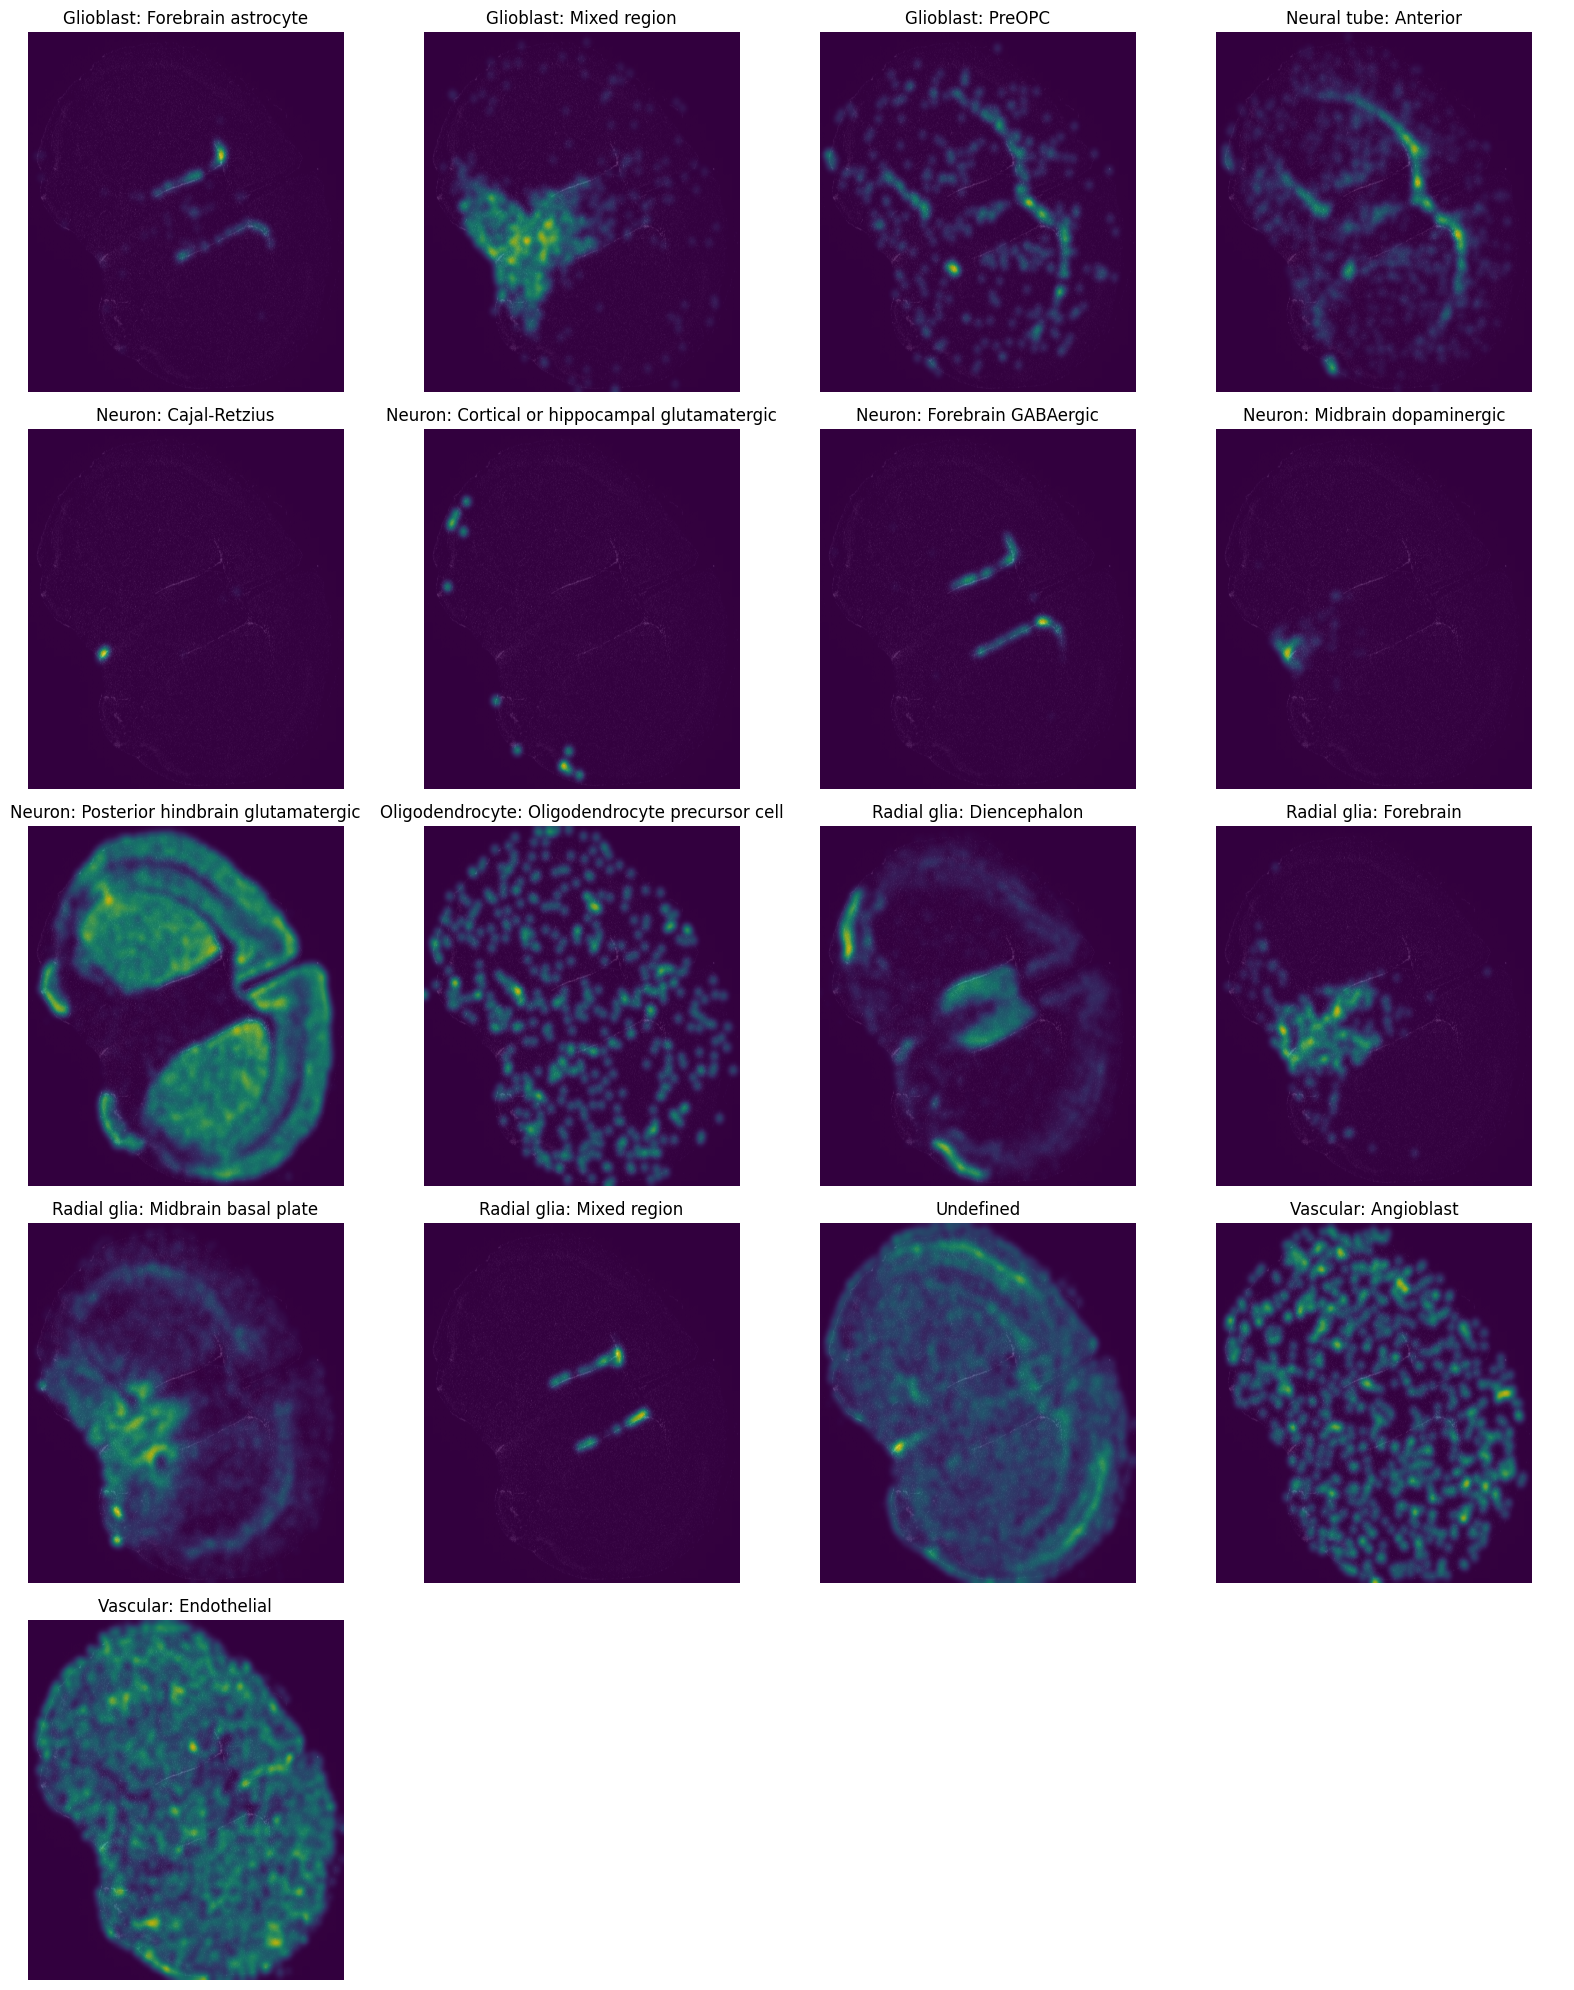

In [ ]:
density_maps = spatial_density_maps(adata, label_key="Cell Type")

> Similarly a heatmap where we can look at where is the cell type and how abundant is the cell type

In [ ]:
spatial_celltype_heatmap(adata, "Radial glia: Diencephalon", mode="sum")

In [ ]:
spatial_celltype_heatmap(adata, ["Radial glia: Diencephalon", "Neuron: Posterior hindbrain glutamatergic"], mode="sum")

In [ ]:
spatial_genes_heatmap(adata, genes="Oxgr1")

In [ ]:
spatial_genes_heatmap(
    adata,
    genes=["Oxgr1", "Htr2a", "Htr1a"],
    mode="mean"
)

> We can look at genes/transcripts with the cell types and try to overlay them together

In [ ]:
compare_gene_heatmap_celltype(
    adata,
    genes=["Ror1", "Ror2", "Ryk"],
    cell_type="Glioblast: Mixed region",
    mode="geometric"
)

> We can quantify/correlate the genes with cell types to get a quantitative assessment

In [ ]:
compare_gene_heatmap_vs_celltype_scatter(
    adata,
    genes=["Htr2a", "Htr1a"],
    cell_type="Neuron: Forebrain GABAergic",
    mode="mean"
)

> What if I want to check a specific gene of interest?
 >1. Is it in my dataset?
 >2. If so, I can plot it across the brain regions?

In [ ]:
"Sox2" in adata.var_names

In [ ]:
genes = ["Sox2", "Fabp7", "Vim", "Htr1a"]

df = pd.DataFrame({
    "Gene": genes,
    "In adata.var_names": [g in adata.var_names for g in genes]
})

df